##🎯 What You Will Learn

✅ **Handle GeoPackage Data:** Load and inspect layers using GeoPandas.

✅ **Geospatial Exploration:**
 Understand structure, geometry, and Coordinate Reference Systems (CRS).

✅ **Data Cleaning:** Handle missing names, remove unnecessary columns, and eliminate duplicates.

✅ **Spatial Calculations:** Reproject datasets and calculate road lengths in kilometers.

✅ **Spatial Aggregation (Dissolve):** Merge fragmented road segments by name to compute true highway lengths.

✅ **Visualization:** Create a vertical bar chart with  correct Arabic text rendering.

✅ Export high-resolution figures (300 DPI)

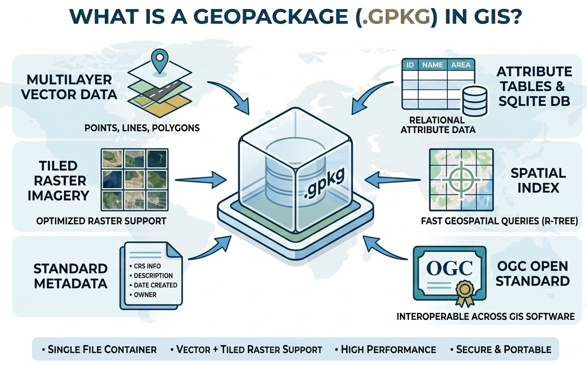

In [ ]:
# Import Libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Define your save folder directory
output_folder = '/content/drive/MyDrive/2-GeoPandas Mini Course/2-GeoPackage Data Handling, CRS & Cleaning/Output'

**Load the dataset**

In [ ]:
# Define Data file Path
file_path = '/content/drive/MyDrive/2-GeoPandas Mini Course/2-GeoPackage Data Handling, CRS & Cleaning/Data/egypt.gpkg'

In [ ]:
# Inspect GeoPackage Layers
file_layers = gpd.list_layers(file_path)
file_layers

In [ ]:
# Load the Roads Layer
roads = gpd.read_file(file_path , layer= 'gis_osm_roads_free')
roads.head()

**Inspect the Dataset**

In [ ]:
# Check dataset shape
roads.shape

In [ ]:
# Check columns
roads.columns

In [ ]:
# Check dataset info
roads.info()

In [ ]:
# Check geometry types
roads.geom_type.unique()

In [ ]:
# Check Coordinate Reference System (CRS)
roads.crs

**Basic Data Cleaning**

In [ ]:
roads.head()

In [ ]:
# Keep only necessary columns
cols = ['fclass', 'name', 'geometry']
roads_sub = roads[cols]

roads_sub

In [ ]:
# Check dupicates data
roads_sub.duplicated().sum()

In [ ]:
# Check missing values
roads_sub.isnull().sum()

In [ ]:
roads_sub.fclass.unique()

In [ ]:
# Filter Primary Roads
primary_roads = roads_sub[roads_sub['fclass'] == 'primary']
primary_roads.head()

In [ ]:
primary_roads.shape

**Reproject to UTM**


In [ ]:
# Convert to UTM Zone 36N (Egypt)
primary_roads = primary_roads.to_crs(epsg=32636)     # This CRS uses meters

**Calculate Road Length**

In [ ]:
# Calculate Road Length
primary_roads["length_m"] = primary_roads.length

primary_roads.head()

In [ ]:
# Convert to kilometers
primary_roads["length_km"] = primary_roads["length_m"] / 1000

primary_roads.head()

In [ ]:
# Total Length of Primary Roads
total_length = primary_roads["length_km"].sum()

print("Total Primary Road Length (km):", round(total_length, 2))

In [ ]:
# Find the Longest Primary Roads
longest_roads = primary_roads.sort_values(
    by="length_km",
    ascending=False
)

# Select the top 10
top10_roads = longest_roads.head(10).reset_index(drop=True)
top10_roads

**Spatial Aggregation (Dissolve)**

In [ ]:
# Filter out rows where name is missing or empty
named_roads = primary_roads[primary_roads['name'].notna() & (primary_roads['name'] != "")]

# Dissolve by name and sum the length_km
# This merges segments into one single entry
roads_dissolved = named_roads.dissolve(by='name', aggfunc={'length_km': 'sum'}).reset_index()

# Get the Top 10
top10 = roads_dissolved.sort_values(by='length_km', ascending=False).head(10).reset_index(drop=True)
top10

**Data Plotting**

In [ ]:
# Install libraries to deal with arabic text
!pip install arabic-reshaper python-bidi

In [ ]:
from arabic_reshaper import reshape
from bidi.algorithm import get_display

# Function to fix Arabic text for Matplotlib
def fix_ar(text):
    return get_display(reshape(str(text)))

# Prepare the data for the axis
names = [fix_ar(n) for n in top10['name']]
lengths = top10['length_km']

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(names, lengths, color='blue')

# 3. Add labels and title
ax.set_title(fix_ar("أطول ١٠ طرق رئيسية في مصر"), fontsize=14)
ax.set_ylabel("Length (km)")
ax.set_xlabel("Road Name")

# Rotate names on the X-axis
plt.xticks(rotation=45, ha='right')

# Add the exact length on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1,
            f'{int(yval)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Save the figure as a high-resolution PNG
#fig.savefig(os.path.join(output_folder, 'top_10_roads_egypt.png'), dpi=300, bbox_inches='tight')   # Uncomment to use
